In [3]:
import sys
#sys.path.append("/home/ubuntu/projects/ts-graph-inference/")
#from ts_graph_inference.data_utils import *
import seaborn as sns
import matplotlib.pyplot as plt
import msprime
import allel
from scipy.spatial.distance import squareform
from sklearn.metrics import pairwise_distances
import numpy as np
import pandas as pd
     
from IPython.display import SVG

In [1]:
import msprime
print(msprime.__file__)

/data/proj2/home/students/u.srinivasan/.conda/envs/scikit-allel/lib/python3.9/site-packages/msprime/__init__.py


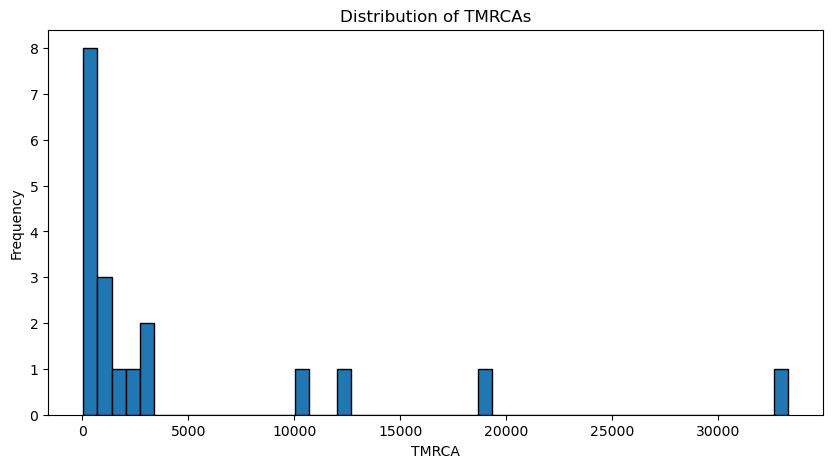

In [7]:

# Simulate ancestry
ts = msprime.sim_ancestry(
    samples=10,
    population_size=10000,
    sequence_length=1e6,
    random_seed=42
)

# Extract TMRCAs
tmrcas = []
for tree in ts.trees():
    for node in tree.nodes():
        if tree.num_children(node) > 1:
            tmrcas.append(tree.time(node))

# Plot TMRCA distribution
plt.figure(figsize=(10, 5))
plt.hist(tmrcas, bins=50, edgecolor='black')
plt.xlabel('TMRCA')
plt.ylabel('Frequency')
plt.title('Distribution of TMRCAs')
plt.show()




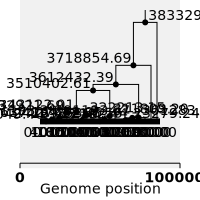

In [8]:
# Plot ARG
ts_simplified = ts.simplify()
node_labels = {
    node.id: f"{node.id}\n{node.time:.2f}"
    for node in ts_simplified.nodes()
}
ts_simplified.draw_svg(
    "arg.svg",
    node_labels=node_labels,
    force_root_branch=True
)


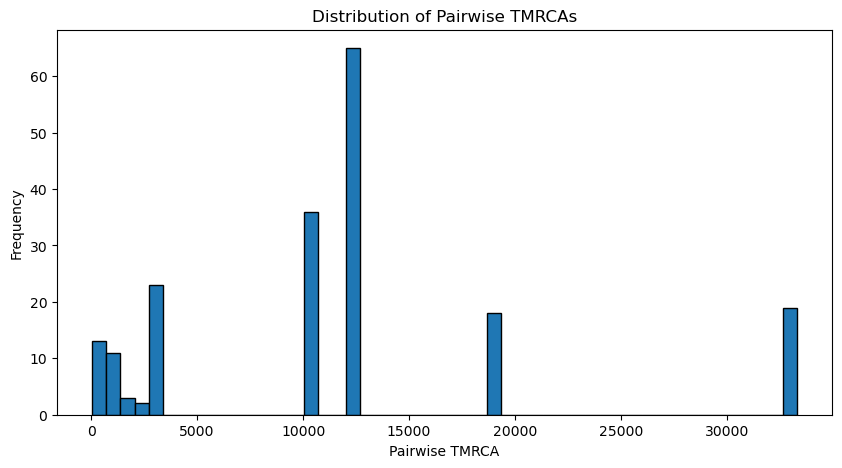

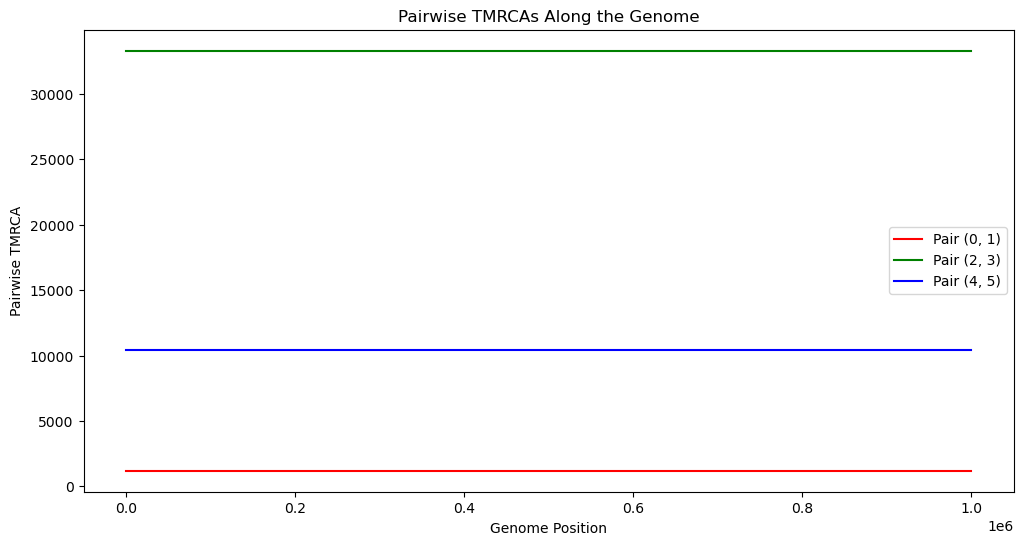

In [9]:
# Extract pairwise TMRCAs
pairwise_tmrcas = []
for tree in ts.trees():
    for a in range(tree.num_samples()):
        for b in range(a + 1, tree.num_samples()):
            pairwise_tmrcas.append(tree.tmrca(a, b))

# Plot pairwise TMRCA distribution
plt.figure(figsize=(10, 5))
plt.hist(pairwise_tmrcas, bins=50, edgecolor='black')
plt.xlabel('Pairwise TMRCA')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise TMRCAs')
plt.show()

# Plot pairwise TMRCAs along the genome
sample_pairs = [(0, 1), (2, 3), (4, 5)]  # Example pairs
colors = ['r', 'g', 'b']
plt.figure(figsize=(12, 6))

for (a, b), color in zip(sample_pairs, colors):
    positions = []
    tmrcas = []
    for tree in ts.trees():
        positions.extend([tree.interval.left, tree.interval.right])
        tmrca = tree.tmrca(a, b)
        tmrcas.extend([tmrca, tmrca])
    plt.step(positions, tmrcas, where='post', color=color, label=f'Pair ({a}, {b})')

plt.xlabel('Genome Position')
plt.ylabel('Pairwise TMRCA')
plt.title('Pairwise TMRCAs Along the Genome')
plt.legend()
plt.show()

In [10]:
pairwise_tmrcas

[1193.3913157636302,
 3122.006915532413,
 33295.27623857282,
 49.39664028650942,
 10402.606293840669,
 10402.606293840669,
 10402.606293840669,
 12432.388623948007,
 18854.693228627555,
 637.1605251135895,
 3122.006915532413,
 12432.388623948007,
 10402.606293840669,
 3122.006915532413,
 2921.6942078544707,
 12432.388623948007,
 12432.388623948007,
 637.1605251135895,
 12432.388623948007,
 3122.006915532413,
 33295.27623857282,
 1193.3913157636302,
 10402.606293840669,
 10402.606293840669,
 10402.606293840669,
 12432.388623948007,
 18854.693228627555,
 1193.3913157636302,
 3122.006915532413,
 12432.388623948007,
 10402.606293840669,
 3122.006915532413,
 2921.6942078544707,
 12432.388623948007,
 12432.388623948007,
 1193.3913157636302,
 12432.388623948007,
 33295.27623857282,
 3122.006915532413,
 10402.606293840669,
 10402.606293840669,
 10402.606293840669,
 12432.388623948007,
 18854.693228627555,
 3122.006915532413,
 289.21741393264136,
 12432.388623948007,
 10402.606293840669,
 2213.

In [5]:
def get_population_time(time_rate:float=0.06, tmax:int = 130_000,
                        num_time_windows:int = 21
                       ) -> np.array :
    """Creates population time points; used as time points to change
    population size changes for simulation
    
    :return numpy.ndarray: time points of length num_time_windows
    """

    population_time = np.repeat([(np.exp(np.log(1 + time_rate * tmax) * i /
                              (num_time_windows - 1)) - 1) / time_rate for i in
                              range(num_time_windows)], 1, axis=0)
    
    population_time[0] = 1
    return population_time, num_time_windows

In [9]:
population_time, r=get_population_time()
population_time

array([1.00000000e+00, 9.42226309e+00, 2.41712687e+01, 4.72584150e+01,
       8.33975512e+01, 1.39967434e+02, 2.28518297e+02, 3.67130131e+02,
       5.84104195e+02, 9.23741463e+02, 1.45538783e+03, 2.28759292e+03,
       3.59027332e+03, 5.62940557e+03, 8.82133225e+03, 1.38177693e+04,
       2.16388711e+04, 3.38815215e+04, 5.30453803e+04, 8.30432543e+04,
       1.30000000e+05])

In [7]:
r

21

In [5]:
def sample_population_size(n_min:int=10, n_max:int=100_000, num_time_windows=21) -> list[float]:

    """Creates random demography. Function taken from: 
    https://gitlab.inria.fr/ml_genetics/public/dlpopsize_paper
    
    :param int n_min: Lower-bound of demography.
    :param int n_max: Upper-bound of demography.
    :param int num_time_windows: Number of population sizes in demography.
    :return list: 
    """

    n_min_log10 = np.log10(n_min)
    n_max_log10 = np.log10(n_max)
    population_size = [10 ** np.random.uniform(low=n_min_log10, high=n_max_log10)]
    for j in range(num_time_windows - 1):
        population_size.append(10 ** n_min_log10 - 1)
        while population_size[-1] > 10 ** n_max_log10 or population_size[-1]  < 10 ** n_min_log10:
            population_size[-1] = population_size[-2] * 10 ** np.random.uniform(-1, 1)

    return population_size


In [51]:
def kingman_constant(Ne=10**4, L=10_000_000, r=5e-8, num_replicates=5, sample_size=10):
    alpha = 2.0
    demography=msprime.Demography()
    demography.add_population(initial_size=(Ne))
    db = msprime.DemographyDebugger(demography=demography)
    tree_sequences = msprime.sim_ancestry(samples=sample_size,
                            recombination_rate=r,
                            sequence_length=L,
                            demography=demography,ploidy=1,random_seed=((alpha+1)**2), num_replicates=num_replicates)
    demography = db.population_size_trajectory(population_time).flatten()
    return list(tree_sequences), demography 




In [7]:

population_size=sample_population_size()
print(population_size)

[5329.589920517362, 25903.83154606096, 52833.336381658686, 10702.46659771702, 1753.747781149474, 420.0763484711836, 170.08900534974154, 295.8747279507895, 175.9430287102604, 308.2279331081826, 460.8890946636557, 74.29139964244376, 98.19008809142356, 25.937727449055533, 224.46923506277196, 1645.2245319360134, 7862.692305610811, 3267.4702441989166, 3867.290183696044, 3101.4234624210335, 349.08988689180137]


In [6]:
trees,demo=kingman_constant()

NameError: name 'kingman_constant' is not defined

In [8]:
def beta_constant(alpha, Ne = 10**6, r=5e-8,  L=10**4, num_replicates=1000, sample_size=10):
    
    
    demography=msprime.Demography()
    demography.add_population(initial_size=(Ne))

    db = msprime.DemographyDebugger(demography=demography,model=msprime.BetaCoalescent(alpha=alpha))
    tree_sequences = msprime.sim_ancestry(samples=10,
                                          recombination_rate=r, sequence_length=L, demography=demography,
                                          ploidy=1,model=msprime.BetaCoalescent(alpha=alpha),
                                          num_replicates=num_replicates)
    demography = db.population_size_trajectory(population_time).flatten()
    
    return list(tree_sequences), demography 

In [12]:
import allel  # Ensure allel is imported for handling HaplotypeArray
import numpy as np
import pandas as pd
from scipy.spatial.distance import squareform, pdist, pdist  # Needed for distance calculations

def treeseq2df(ts, addedhue=None, w=100):
    # Create HaplotypeArray from the genotype matrix of the tree sequence
    gn = allel.HaplotypeArray(ts.genotype_matrix())
    
    # Compute Rogers-Huff distances
    r = allel.rogers_huff_r(gn)
    s = squareform(r ** 2)  # Square the Rogers-Huff distances and convert to a square form
    s = np.triu(s)  # Take the upper triangle of the distance matrix
    n_genotypes = s.shape[0]
    
    # Melt the distance matrix into long format
    m = pd.DataFrame(s).melt()
    m.columns = ["genotype1", "distance"]
    m["genotype2"] = np.tile(np.arange(n_genotypes), n_genotypes)
    
    # Retrieve positions from the sites in the tree sequence
    positions = [s.position for s in ts.sites()]
    m["position"] = np.tile(positions, n_genotypes)
    
    # Compute pairwise distances from positions
    distance = pairwise_distances(np.array(positions).reshape(-1, 1))
    pairdistances = pd.DataFrame(distance).melt().value.tolist()
    m["pairdistances"] = pairdistances
    
    if addedhue:
        m["hue"] = addedhue  # Add hue if provided

    # Filter the melted DataFrame for relevant distances
    sm = m[m["distance"] >= 0.01]
    
    # Bin pair distances and calculate the mean for each bin
    sm['binned'] = pd.cut(x=sm['pairdistances'], bins=np.linspace(0, ts.sequence_length, w))
    df2 = sm[["distance", "binned", "hue"]].groupby('binned').mean().reset_index()

    # Add position from the left edge of each bin
    df2["position"] = df2['binned'].apply(lambda x: x.left)
    
    return df2


In [52]:
L = 0.5 * 10**6
kingman_trees,_=kingman_constant(Ne=10**4, L=L,  r=1e-8, sample_size=10)

In [53]:
# Save each replicate as a .trees file
for i, ts in enumerate(kingman_trees):
    filename = f"replicate_{i}.trees"
    ts.dump(filename)
    print(f"Saved {filename}")

Saved replicate_0.trees
Saved replicate_1.trees
Saved replicate_2.trees
Saved replicate_3.trees
Saved replicate_4.trees


In [55]:
kingman_trees[1]

In [7]:
L = 0.5 * 10**6
beta_trees,_=beta_constant(Ne=10**4, L=L,  r=1e-8, sample_size=10,alpha=1.5)

In [23]:
for tree_index, tree_sequence in enumerate(beta_trees):
    for tree_index, tree in enumerate(tree_sequence.trees()):
        for node in tree.nodes():
            if tree.parent(node) != -1:  # Exclude root and samples
                coalescent_time = tree.time(tree.parent(node)) - tree.time(node)
                # Here you can process or store the coalescent_time as needed

In [29]:
def extract_coalescent_times(beta_trees):
    coalescent_data = []
    
    for tree_sequence_index, tree_sequence in enumerate(beta_trees):  # Loop over tree sequences
        for tree_index, tree in enumerate(tree_sequence.trees()):  # Loop over individual trees
            for node in tree.nodes():  # Loop over each node in the tree
                if tree.is_sample(node):  # Skip the sample nodes (no coalescent event)
                    continue
                
                parent = tree.parent(node)
                
                # Only process internal nodes (those with parents)
                if parent != -1:
                    coalescent_time = tree.time(parent) - tree.time(node)
                    
                    coalescent_data.append({
                        'tree_sequence_index': tree_sequence_index,  # Index of tree sequence in the list
                        'tree_index': tree_index,                    # Index of tree in the sequence
                        'node': node,                                # Node ID in the tree
                        'parent': parent,                            # Parent node ID
                        'coalescent_time': coalescent_time,          # Coalescence time (TMRCA)
                        'tree_left': tree.interval[0],               # Start of the interval
                        'tree_right': tree.interval[1]               # End of the interval
                    })
    
    return coalescent_data


In [38]:
import numpy as np
import msprime

Ne = 10**4
L = 10_000_000
r = 5e-8
num_replicates = 2
sample_size = 10
alpha = 1.9

# Define the expansion parameters
expansion_time = 1000  # Time of expansion in generations ago
expansion_factor = 5  # Population size will increase by this factor

# Create the demography with expansion
demography = msprime.Demography()
demography.add_population(name="pop", initial_size=Ne)
demography.add_population_parameters_change(time=expansion_time, initial_size=Ne/expansion_factor, population="pop")

tmrca = np.zeros(num_replicates)
db = msprime.DemographyDebugger(demography=demography, model=msprime.BetaCoalescent(alpha=alpha))

# Run the simulation
replicates = msprime.sim_ancestry(
    samples=sample_size,
    recombination_rate=r,
    sequence_length=L,
    demography=demography,
    ploidy=1,
    model=msprime.BetaCoalescent(alpha=alpha),
    num_replicates=num_replicates
)

# Calculate TMRCA for each replicate
for replicate_index, ts in enumerate(replicates):
    tree = ts.first()
    tmrca[replicate_index] = tree.time(tree.root)

# Print results
print(f"Mean TMRCA: {np.mean(tmrca)}")
print(f"Variance of TMRCA: {np.var(tmrca)}")




Mean TMRCA: 979.0106899339546
Variance of TMRCA: 6223.328714432882


In [37]:
tmrca


array([1168.17011282])

In [25]:
# Optional: Plot the population size trajectory
import matplotlib.pyplot as plt

def plot_population_size_trajectory(db):
    times, sizes, db.population_size_trajectory()
    plt.line(times, sizes, where="post")
    plt.xlabel("Time (generations ago)")
    plt.ylabel("Population size")
    plt.title("Population Size Trajectory")
    plt.xscale("log")
    plt.yscale("log")
    plt.show()

plot_population_size_trajectory(db)



(1048.8297385045976, 501390.7302752362)